In [129]:
import requests
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [21]:
lims = [-127.376, -112.412, 31.166, 42.656]

In [97]:
url = 'https://earthquake.usgs.gov/fdsnws/event/1/query'
query = {
    "format": "geojson",
    "starttime": '2022-01-01',
    "minmagnitude": '5.5',
    "minlongitude": lims[0],
    "maxlongitude": lims[1],
    "minlatitude": lims[2],
    "maxlatitude": lims[3],
    
}
r = requests.get(url, params=query)

if r.status_code == 200:
    data = r.json()
else: 
    print("error")

In [98]:
data

{'type': 'FeatureCollection',
 'metadata': {'generated': 1778120952000,
  'url': 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2022-01-01&minmagnitude=5.5&minlongitude=-127.376&maxlongitude=-112.412&minlatitude=31.166&maxlatitude=42.656',
  'title': 'USGS Earthquakes',
  'status': 200,
  'api': '2.4.0',
  'count': 7},
 'features': [{'type': 'Feature',
   'properties': {'mag': 5.68,
    'place': '20 km ESE of Silver Springs, Nevada',
    'time': 1776130152123,
    'updated': 1778031554890,
    'tz': None,
    'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/nn00914068',
    'detail': 'https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nn00914068&format=geojson',
    'felt': 6515,
    'cdi': 5.6,
    'mmi': 6.981,
    'alert': 'green',
    'status': 'reviewed',
    'tsunami': 0,
    'sig': 1056,
    'net': 'nn',
    'code': '00914068',
    'ids': ',ew1776130160,us6000sptw,nn00914068,usauto6000sptw,',
    'sources': ',ew,us,nn,usauto,',
    'typ

In [99]:
silversprings = data['features'][3]
ss_detail_url = silversprings['properties']['detail']
r2 = requests.get(ss_detail_url)
ss_detail = r2.json()
eew_url = ss_detail['properties']['products']['shake-alert'][-1]['contents']['summary.json']['url']
r3 = requests.get(eew_url)
eew_data = r3.json()


In [118]:
features = eew_data['alerts']
pprint.pprint(eew_data['alerts'])

target_mmi = 4

poly = None
for mmi in range(target_mmi,0,-1):
    print(mmi)
    poly = next((feature for feature in features 
                 if feature['properties'].get('name') == f'MMI {mmi}'))
    if poly:
        break
if poly:
    verts = poly['geometry']['coordinates'][0]
else:
    print("No polygon")

[{'features': [{'geometry': {'coordinates': [-125.0059, 40.2784],
                             'type': 'Point'},
                'id': 'SAinitloc',
                'properties': {'circletime': 0.0,
                               'color': '#000000',
                               'fill-opacity': 1,
                               'radius': 5000.0,
                               'radiusunits': 'm',
                               'title': 'Initial SA Loc',
                               'tunits': 's'},
                'type': 'Feature'},
               {'geometry': {'coordinates': [-125.025169, 40.369835],
                             'type': 'Point'},
                'id': 'Epicenter',
                'properties': {'icon': 'epicenter',
                               'title': 'Earthquake Epicenter'},
                'type': 'Feature'},
               {'geometry': {'coordinates': [[[-125.0059, 41.0667],
                                              [-124.2692, 40.8335],
                   

StopIteration: 

In [146]:
sa_feats = eew_data['alerts'][['id']=='finalAlertCollection']['features']
pprint(sa_feats)

[{'geometry': {'coordinates': [-125.0059, 40.2784], 'type': 'Point'},
  'id': 'SAinitloc',
  'properties': {'circletime': 0.0,
                 'color': '#000000',
                 'fill-opacity': 1,
                 'radius': 5000.0,
                 'radiusunits': 'm',
                 'title': 'Initial SA Loc',
                 'tunits': 's'},
  'type': 'Feature'},
 {'geometry': {'coordinates': [-125.025169, 40.369835], 'type': 'Point'},
  'id': 'Epicenter',
  'properties': {'icon': 'epicenter', 'title': 'Earthquake Epicenter'},
  'type': 'Feature'},
 {'geometry': {'coordinates': [[[-125.0059, 41.0667],
                                [-124.2692, 40.8335],
                                [-123.9726, 40.2738],
                                [-124.2812, 39.7187],
                                [-125.0059, 39.4901],
                                [-125.7306, 39.7187],
                                [-126.0392, 40.2738],
                                [-125.7426, 40.8335],
        

In [144]:
for feature in sa_feats:
    pprint(feature)
    # print('\n\n\n\n\n\n\n\n\n\n\n')

{'geometry': {'coordinates': [-125.0059, 40.2784], 'type': 'Point'},
 'id': 'SAinitloc',
 'properties': {'circletime': 0.0,
                'color': '#000000',
                'fill-opacity': 1,
                'radius': 5000.0,
                'radiusunits': 'm',
                'title': 'Initial SA Loc',
                'tunits': 's'},
 'type': 'Feature'}
{'geometry': {'coordinates': [-125.025169, 40.369835], 'type': 'Point'},
 'id': 'Epicenter',
 'properties': {'icon': 'epicenter', 'title': 'Earthquake Epicenter'},
 'type': 'Feature'}
{'geometry': {'coordinates': [[[-125.0059, 41.0667],
                               [-124.2692, 40.8335],
                               [-123.9726, 40.2738],
                               [-124.2812, 39.7187],
                               [-125.0059, 39.4901],
                               [-125.7306, 39.7187],
                               [-126.0392, 40.2738],
                               [-125.7426, 40.8335],
                               [

In [115]:
target_mmis = np.arange(4.5,0,-0.5)
print(f'MMI {[mmi for mmi in target_mmis]}')

MMI [np.float64(4.5), np.float64(4.0), np.float64(3.5), np.float64(3.0), np.float64(2.5), np.float64(2.0), np.float64(1.5), np.float64(1.0), np.float64(0.5)]


In [101]:
epix, epiy = eew_data['alerts'][['id']=='maxMAlertCollection']['features'][['id']=='Epicenter']['geometry']['coordinates']

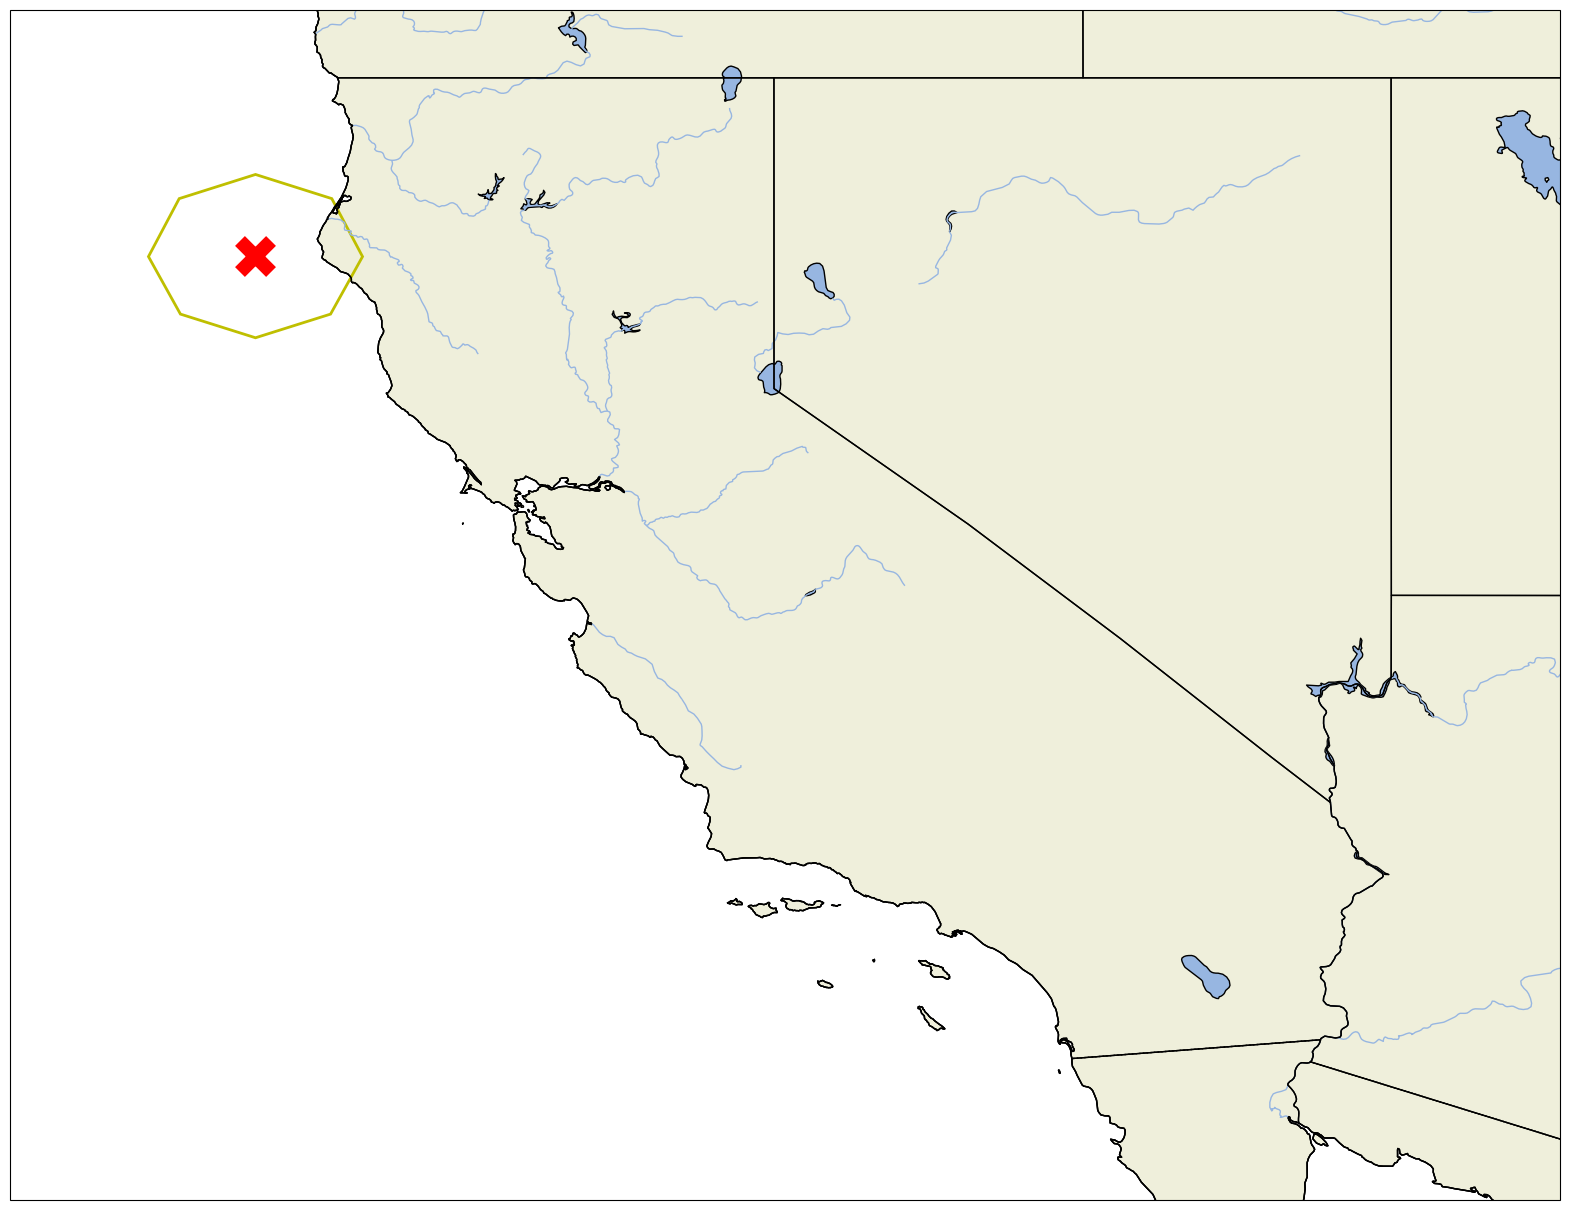

In [102]:
fig, axi = plt.subplots(1,1,figsize=(20,20), subplot_kw={'projection': ccrs.PlateCarree()})

axi.set_extent(lims)

axi.add_feature(cfeature.COASTLINE)
axi.add_feature(cfeature.BORDERS, linestyle=':')
axi.add_feature(cfeature.LAND, edgecolor='black')
axi.add_feature(cfeature.LAKES, edgecolor='black')
axi.add_feature(cfeature.RIVERS)
axi.add_feature(cfeature.STATES)

axi.scatter(epix,epiy,c='r',marker='x',linewidths=10,s=500)

eew_poly = Polygon(verts,fill=False,edgecolor='y',linewidth=2)
axi.add_patch(eew_poly)

In [43]:
eew_url

'https://earthquake.usgs.gov/product/shake-alert/ew1777623450/ew/1777623952302/summary.json'